<a href="https://colab.research.google.com/github/MottuqeBrid/TensorFlow/blob/main/4/gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [3]:
import tarfile
import pickle
import os

# Extract
# tar_path = r"D:\Python\TensorFlow\cifar-10-python.tar.gz"
tar_path = "cifar-10-python.tar.gz"

with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall("cifar-10-data")


# Load batch
def load_batch(file_path):
    with open(file_path, "rb") as file:
        data = pickle.load(file, encoding="bytes")

    return data[b"data"], data[b"labels"]


data_dir = "cifar-10-data/cifar-10-batches-py"


# Training data
x_train = []
y_train = []

for i in range(1, 6):
    images, labels = load_batch(os.path.join(data_dir, f"data_batch_{i}"))

    x_train.append(images)
    y_train.extend(labels)


# Test data
x_test, y_test = load_batch(os.path.join(data_dir, "test_batch"))


x_train = np.concatenate(x_train)
y_train = np.array(y_train)

y_test = np.array(y_test)

# Reshape images
x_train = x_train.reshape(-1, 3, 32, 32)
x_test = x_test.reshape(-1, 3, 32, 32)

x_train = x_train.transpose(0, 2, 3, 1)
x_test = x_test.transpose(0, 2, 3, 1)


print("Training:", x_train.shape, y_train.shape)
print("Testing:", x_test.shape, y_test.shape)

C:\Users\USER\AppData\Local\Temp\ipykernel_4340\2389668390.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("cifar-10-data")


Training: (50000, 32, 32, 3) (50000,)
Testing: (10000, 32, 32, 3) (10000,)


In [21]:
x_train.shape

(50000, 32, 32, 3)

In [22]:
x_train[0].shape

(32, 32, 3)

In [6]:
y_train.shape

(50000,)

In [7]:
y_train[:5]

array([6, 9, 9, 4, 1])

In [8]:
def plot_sample(index):
    plt.figure(figsize=(10, 1))
    plt.imshow(x_train[index])
    plt.show()

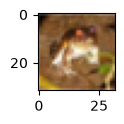

In [9]:
plot_sample(0)

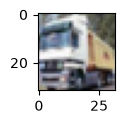

In [10]:
plot_sample(1)

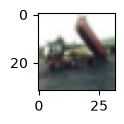

In [11]:
plot_sample(2)

In [12]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

In [13]:
class_names[y_train[0]]

'frog'

In [14]:
y_train[0]

np.int64(6)

In [23]:
x_train_scaled = x_train / 255
x_test_scaled = x_test / 255

In [16]:
x_train_scaled.shape

(50000, 32, 32, 3)

In [17]:
y_train[:5]

array([6, 9, 9, 4, 1])

In [18]:
y_train_catagorical = keras.utils.to_categorical(
    y_train,
    num_classes=10,
    # dtype="float32"
)
y_train_catagorical[:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [19]:
y_test_catagorical = keras.utils.to_categorical(
    y_test,
    num_classes=10,
    # dtype="float32"
)
y_test_catagorical[:5]

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]])

In [26]:
model = keras.Sequential(
    [
        keras.layers.Flatten(input_shape=(32, 32, 3)),
        keras.layers.Dense(3000, activation="relu"),
        keras.layers.Dense(1000, activation="relu"),
        keras.layers.Dense(10, activation="sigmoid"),
    ]
)
model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

model.fit(x_train_scaled, y_train_catagorical, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - accuracy: 0.3527 - loss: 1.8140
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.4254 - loss: 1.6237
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.4572 - loss: 1.5404
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.4767 - loss: 1.4806
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.4964 - loss: 1.4291


In [31]:
y_pred = model.predict(x_test_scaled)
y_pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


array([0.3037053 , 0.7081176 , 0.784056  , 0.9344465 , 0.37775648,
       0.8084008 , 0.7990754 , 0.04540788, 0.67643654, 0.18402958],
      dtype=float32)

In [30]:
model.evaluate(x_test_scaled, y_test_catagorical)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4854 - loss: 1.4495


[1.4495353698730469, 0.48539999127388]

In [32]:
np.argmax(y_pred[0])

np.int64(3)

In [33]:
class_names[y_test[0]]

'cat'

In [ ]:
def get_model():
    model = keras.Sequential(
        [
            keras.layers.Flatten(input_shape=(32, 32, 3)),
            keras.layers.Dense(3000, activation="relu"),
            keras.layers.Dense(1000, activation="relu"),
            keras.layers.Dense(10, activation="sigmoid"),
        ]
    )
    model.compile(
        optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model